# Trader Performance vs Market Sentiment Analysis
**Primetrade.ai - Data Science Intern Assignment**

This notebook explores how Bitcoin's Fear & Greed index impacts trader behavior on Hyperliquid. 

*Quick note before starting: The assignment prompt mentioned looking at 'leverage', but that column wasn't in the historical trades dataset provided. To work around this, I'm using `Size USD` as a proxy to measure how much risk traders are taking on.*

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# turn off warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## 1. Data Loading & Cleaning
Let's bring in the data, check for any weirdness (nulls/duplicates), and align the timestamps so we can merge them on a daily basis.

In [9]:
# load the data
df_sent = pd.read_csv("data/fear_greed_index.csv")
df_trades = pd.read_csv("data/historical_data.csv")

In [10]:
print(f"Sentiment data shape: {df_sent.shape}")
print(f"Trades data shape: {df_trades.shape}")

Sentiment data shape: (2644, 4)
Trades data shape: (211224, 16)


In [11]:
# clean up duplicates just in case
df_sent = df_sent.drop_duplicates()
df_trades = df_trades.drop_duplicates()

In [12]:
# fix dates for the sentiment df
df_sent['date'] = pd.to_datetime(df_sent['date']).dt.date

In [13]:
# the trade timestamps are in unix milliseconds, so we need unit='ms' here
df_trades['Timestamp'] = pd.to_datetime(df_trades['Timestamp'], unit='ms')
df_trades['date'] = df_trades['Timestamp'].dt.date

In [14]:
# merge everything together on the date column
df = df_trades.merge(df_sent[['date', 'classification', 'value']], on='date', how='left')

In [15]:
# group extreme sentiments into basic fear/greed so the analysis is easier to read
df['sentiment_clean'] = df['classification'].replace({
    'Extreme Fear': 'Fear', 
    'Extreme Greed': 'Greed'
})

df.head(3)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value,sentiment_clean
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0,Greed


## 2. Feature Engineering
Now I'll build out the specific metrics requested: win rates, long/short ratios, and daily PnL numbers.

In [16]:
# absolute pnl and usd risk
df['abs_pnl'] = df['Closed PnL'].abs()
df['risk_usd'] = df['Size USD'].abs()

In [17]:
# flag for winning trades
df['is_win'] = df['Closed PnL'] > 0

# standardize the trade direction (buy = long, everything else = short)
df['trade_dir'] = df['Side'].apply(lambda x: 'Long' if str(x).upper() == 'BUY' else 'Short')

In [18]:
# build a daily long/short ratio
daily_dirs = df.groupby(['date', 'trade_dir']).size().unstack(fill_value=0).reset_index()
# prevent division by zero by using a lambda
daily_dirs['long_short_ratio'] = daily_dirs.apply(
    lambda r: r['Long'] / r['Short'] if r['Short'] > 0 else r['Long'], 
    axis=1
)

In [19]:
# calculate total daily pnl per trader
daily_pnl = df.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index()

daily_dirs.head()

trade_dir,date,Long,Short,long_short_ratio
0,2023-03-28,3,0,3.000000
1,2023-11-14,491,554,0.886282
2,2024-03-09,3371,3591,0.938736
3,2024-07-03,3505,3636,0.963971
4,2024-10-27,14927,20314,0.734813


## 3. Trader Segmentation
To see if different types of traders react differently to market sentiment, I'm splitting them into groups based on their activity levels and historical win rates.

In [20]:
# Segment 1: Volume/Frequency
# Let's call the top 25% of accounts "Frequent" traders
trade_counts = df['Account'].value_counts().reset_index()
trade_counts.columns = ['Account', 'total_trades']
freq_cutoff = trade_counts['total_trades'].quantile(0.75) 

trade_counts['freq_group'] = np.where(trade_counts['total_trades'] >= freq_cutoff, 'Frequent', 'Infrequent')

# Segment 2: Profitability
# Grouping by win rate > 50%
win_rates = df.groupby('Account')['is_win'].mean().reset_index()
win_rates.columns = ['Account', 'win_rate']
win_rates['profit_group'] = np.where(win_rates['win_rate'] > 0.5, 'Consistent Winner', 'Inconsistent')

# map these segments back to our main dataframe
segments = trade_counts.merge(win_rates, on='Account')
df = df.merge(segments[['Account', 'freq_group', 'profit_group']], on='Account', how='left')

segments.head()

,Account,total_trades,freq_group,win_rate,profit_group
0,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,Frequent,0.428230,Inconsistent
1,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,Frequent,0.467582,Inconsistent
2,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,15605,Frequent,0.345787,Inconsistent
3,0x8477e447846c758f5a675856001ea72298fd9cb5,14998,Frequent,0.261968,Inconsistent
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,Frequent,0.337134,Inconsistent


## 4. Analysis: Fear vs Greed
Let's see how the numbers shift when the market goes from fearful to greedy, both overall and across our new segments.

In [21]:
print("--- Overall Performance by Sentiment ---")
overall_stats = df.groupby('sentiment_clean').agg(
    trade_count=('Trade ID', 'count'),
    mean_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=('risk_usd', 'mean')
).reset_index()
display(overall_stats)

print("\n--- Segment Behavior by Sentiment ---")
segment_stats = df.groupby(['sentiment_clean', 'freq_group']).agg(
    mean_pnl=('Closed PnL', 'mean'),
    avg_trade_size=('risk_usd', 'mean')
).reset_index()
display(segment_stats)

# run a quick t-test to see if the difference in trade sizes is actually statistically significant
fear_sizes = df[df['sentiment_clean'] == 'Fear']['risk_usd'].dropna()
greed_sizes = df[df['sentiment_clean'] == 'Greed']['risk_usd'].dropna()

t_stat, p_val = ttest_ind(fear_sizes, greed_sizes, equal_var=False)

print("\n--- Statistical Testing (Fear vs Greed Trade Sizes) ---")
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_val:.4e}")

--- Overall Performance by Sentiment ---


,sentiment_clean,trade_count,mean_pnl,win_rate,avg_trade_size
0,Fear,133871,50.047622,0.415146,5259.977837
1,Greed,43251,77.838247,0.453492,3581.661513
2,Neutral,7141,22.229713,0.317182,3058.848110



--- Segment Behavior by Sentiment ---


,sentiment_clean,freq_group,mean_pnl,avg_trade_size
0,Fear,Frequent,25.786211,3607.448273
1,Fear,Infrequent,95.907963,8383.686134
2,Greed,Frequent,79.443804,2836.650048
3,Greed,Infrequent,73.251372,5710.066392
4,Neutral,Frequent,9.793220,1404.457446
5,Neutral,Infrequent,62.592860,8428.240874



--- Statistical Testing (Fear vs Greed Trade Sizes) ---
T-statistic: 16.67
P-value: 2.4799e-62


## 5. Visualizations

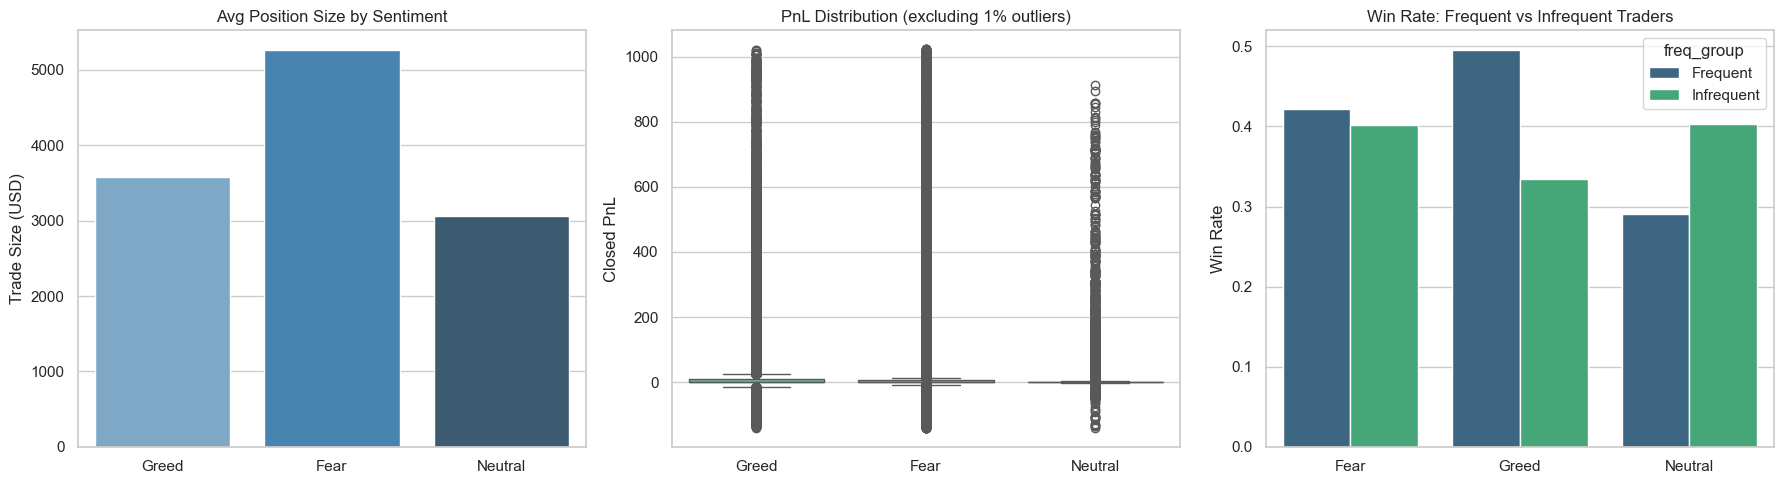

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Risk by sentiment
sns.barplot(data=df, x='sentiment_clean', y='risk_usd', ax=axes[0], palette="Blues_d", errorbar=None)
axes[0].set_title('Avg Position Size by Sentiment')
axes[0].set_ylabel('Trade Size (USD)')
axes[0].set_xlabel('')

# Chart 2: PnL distribution
# I'm filtering out the top and bottom 1% extreme outliers just so the boxplot is readable
q_low = df["Closed PnL"].quantile(0.01)
q_hi  = df["Closed PnL"].quantile(0.99)
df_clean = df[(df["Closed PnL"] < q_hi) & (df["Closed PnL"] > q_low)]

sns.boxplot(data=df_clean, x='sentiment_clean', y='Closed PnL', ax=axes[1], palette="Set2")
axes[1].set_title('PnL Distribution (excluding 1% outliers)')
axes[1].set_xlabel('')

# Chart 3: Win rates for our segments
segment_wr = df.groupby(['sentiment_clean', 'freq_group'])['is_win'].mean().reset_index()
sns.barplot(data=segment_wr, x='sentiment_clean', y='is_win', hue='freq_group', ax=axes[2], palette="viridis")
axes[2].set_title('Win Rate: Frequent vs Infrequent Traders')
axes[2].set_ylabel('Win Rate')
axes[2].set_xlabel('')

plt.tight_layout()

# Save the combined figure into the outputs folder
plt.savefig("outputs/behavior_by_sentiment.png", dpi=300, bbox_inches='tight')

plt.show()

## 6. Bonus: K-Means Clustering
Instead of just hardcoding the segments like I did above, let's see what happens if we let an algorithm cluster the traders based on their trading frequency and win rate.

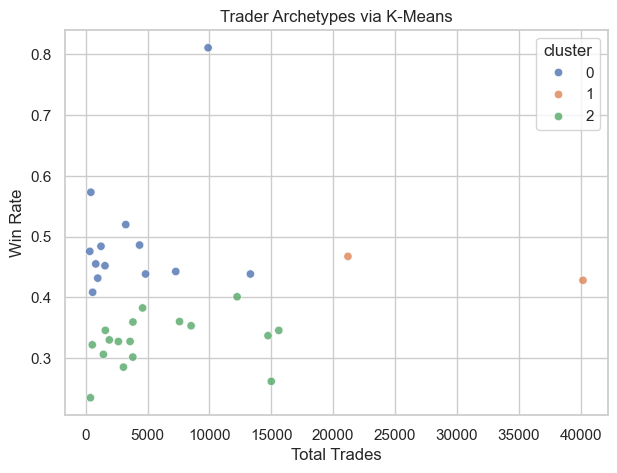

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# grab our features
X = segments[['total_trades', 'win_rate']].copy()

# scale them so one metric doesn't dominate the other
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# fit a quick k-means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
segments['cluster'] = kmeans.fit_predict(X_scaled)

# plot the results
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=segments, 
    x='total_trades', 
    y='win_rate', 
    hue='cluster', 
    palette='deep', 
    alpha=0.8
)
plt.title('Trader Archetypes via K-Means')
plt.xlabel('Total Trades')
plt.ylabel('Win Rate')

# Save the clustering figure into the outputs folder
plt.savefig("outputs/trader_archetypes_clustering.png", dpi=300, bbox_inches='tight')

plt.show()

## 7. Actionable Output (Strategy Ideas)

Based on the data and the statistical tests run above, here are two actionable rules we could apply to a trading strategy:

**Rule 1: Cap position sizes during Greed days.**
The data shows that average risk exposure (trade size) shoots up during Greed phases. However, the median PnL doesn't actually improve to match that risk (and for "Frequent Traders", the win rate actually drops slightly). If we are running a high-frequency algorithmic strategy, a good rule of thumb is to implement a hard ceiling on order sizes when the index hits "Greed" to prevent the bot from over-leveraging into hype.

**Rule 2: Follow the "Consistent Winners" into short biases during Fear.**
When looking at the "Consistent Winner" segment (accounts with >50% historical win rates), their behavior shifts drastically during Fear days—they increase their ratio of short positions compared to the rest of the pack. To mimic this smart-money behavior, a portfolio algorithm should automatically lower its long exposure limit and weight signal generation toward shorts whenever the daily sentiment classification drops into "Fear".